In [2]:
from analysis import (
    load_data, descriptive_stats, normality_tests, levene_tests,
    one_way_anova, tukey_posthoc, proliferation_ttest
)
from visualize import generate_all_figures

In [1]:
import os
os.chdir('..')

import sys
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 4)

# MTT Assay Analysis: MG-63 Osteoblast Viability on TiO2/Sr Electrospun-Coated 316L Stainless Steel

**Author:** Shahrzad Rofoee | Materials Engineering, M.Sc. Research

> **Note on data provenance:** All absorbance data in this notebook are original experimental
> measurements collected during my Master's research (plate-reader OD 570 nm readings) as part
> of a project evaluating strontium-doped TiO2 nanofiber coatings (single-nozzle vs. dual-nozzle
> electrospinning) on 316L stainless steel for orthopedic implant applications — not simulated
> or synthetic data.

---

### Contents
1. Background
2. Objectives
3. Data Loading
4. Descriptive Statistics
5. Assumption Checks (Normality, Variance Homogeneity)
6. One-Way ANOVA
7. Tukey HSD Post-Hoc Comparisons
8. Proliferation Analysis (Day 1 to Day 3)
9. Visualizations
10. Summary & Conclusions

In [ ]:
df = load_data()
df.head(10)

,day,group,replicate,absorbance
0,1,control,1,0.345
1,1,control,2,0.341
2,1,control,3,0.352
3,1,control,4,0.349
4,1,DN,1,0.306
5,1,DN,2,0.304
6,1,DN,3,0.315
7,1,DN,4,0.320
8,1,SN,1,0.245
9,1,SN,2,0.236


In [5]:
summary = descriptive_stats(df)
summary

,day,group,mean,std,n,viability_percent
0,1,DN,0.3113,0.0075,4,89.7621
1,1,SN,0.2450,0.0113,4,70.6561
2,1,TiO2,0.3193,0.0132,4,92.0692
3,1,control,0.3468,0.0048,4,100.0000
4,3,DN,0.4755,0.0105,4,92.9165
5,3,SN,0.3785,0.0152,4,73.9619
6,3,TiO2,0.4982,0.0136,4,97.3620
7,3,control,0.5118,0.0077,4,100.0000


In [6]:
normality_df = normality_tests(df)
normality_df

,day,group,shapiro_stat,shapiro_p,normal_at_0.05
0,1,DN,0.9141,0.5044,True
1,1,SN,0.8720,0.3054,True
2,1,TiO2,0.8463,0.2143,True
3,1,control,0.9841,0.9254,True
4,3,DN,0.9658,0.8150,True
5,3,SN,0.8505,0.2277,True
6,3,TiO2,0.9632,0.7988,True
7,3,control,0.9266,0.5746,True


In [7]:
levene_df = levene_tests(df)
levene_df

,day,levene_stat,levene_p,equal_variance_at_0.05
0,1,0.7402,0.5482,True
1,3,1.3404,0.3075,True


In [8]:
anova_df = one_way_anova(df)
anova_df

,day,F_statistic,p_value,eta_squared,significant_at_0.05
0,1,77.6725,3.9614e-08,0.9510,True
1,3,99.0464,9.8644e-09,0.9612,True


In [9]:
tukey_dict = tukey_posthoc(df)
print("Day 1:")
display(tukey_dict[1])
print("Day 3:")
display(tukey_dict[3])

Day 1:


,day,group1,group2,meandiff,p-adj,lower,upper,reject
0,1,DN,SN,-0.0663,0.0000,-0.0868,-0.0457,True
1,1,DN,TiO2,0.0080,0.6642,-0.0126,0.0286,False
2,1,DN,control,0.0355,0.0012,0.0149,0.0561,True
3,1,SN,TiO2,0.0742,0.0000,0.0537,0.0948,True
4,1,SN,control,0.1017,0.0000,0.0812,0.1223,True
5,1,TiO2,control,0.0275,0.0087,0.0069,0.0481,True


Day 3:


,day,group1,group2,meandiff,p-adj,lower,upper,reject
0,3,DN,SN,-0.0970,0.0000,-0.1224,-0.0716,True
1,3,DN,TiO2,0.0227,0.0849,-0.0027,0.0482,False
2,3,DN,control,0.0363,0.0055,0.0108,0.0617,True
3,3,SN,TiO2,0.1198,0.0000,0.0943,0.1452,True
4,3,SN,control,0.1333,0.0000,0.1078,0.1587,True
5,3,TiO2,control,0.0135,0.4260,-0.0119,0.0389,False


In [10]:
proliferation_df = proliferation_ttest(df)
proliferation_df

,group,day1_mean,day3_mean,fold_change,t_statistic,p_value,significant_at_0.05
0,DN,0.3113,0.4755,1.5277,-25.4519,7.0486e-07,True
1,SN,0.2450,0.3785,1.5449,-14.0787,1.4858e-05,True
2,TiO2,0.3192,0.4982,1.5607,-18.8552,1.4500e-06,True
3,control,0.3467,0.5118,1.4758,-36.3318,2.9020e-07,True


In [11]:
generate_all_figures(df, summary)

Saved figure to figures/01_absorbance_bar.png
Saved figure to figures/02_viability_percent.png
Saved figure to figures/03_boxplot_distribution.png
Saved figure to figures/04_proliferation_trend.png
Saved figure to figures/05_viability_heatmap.png


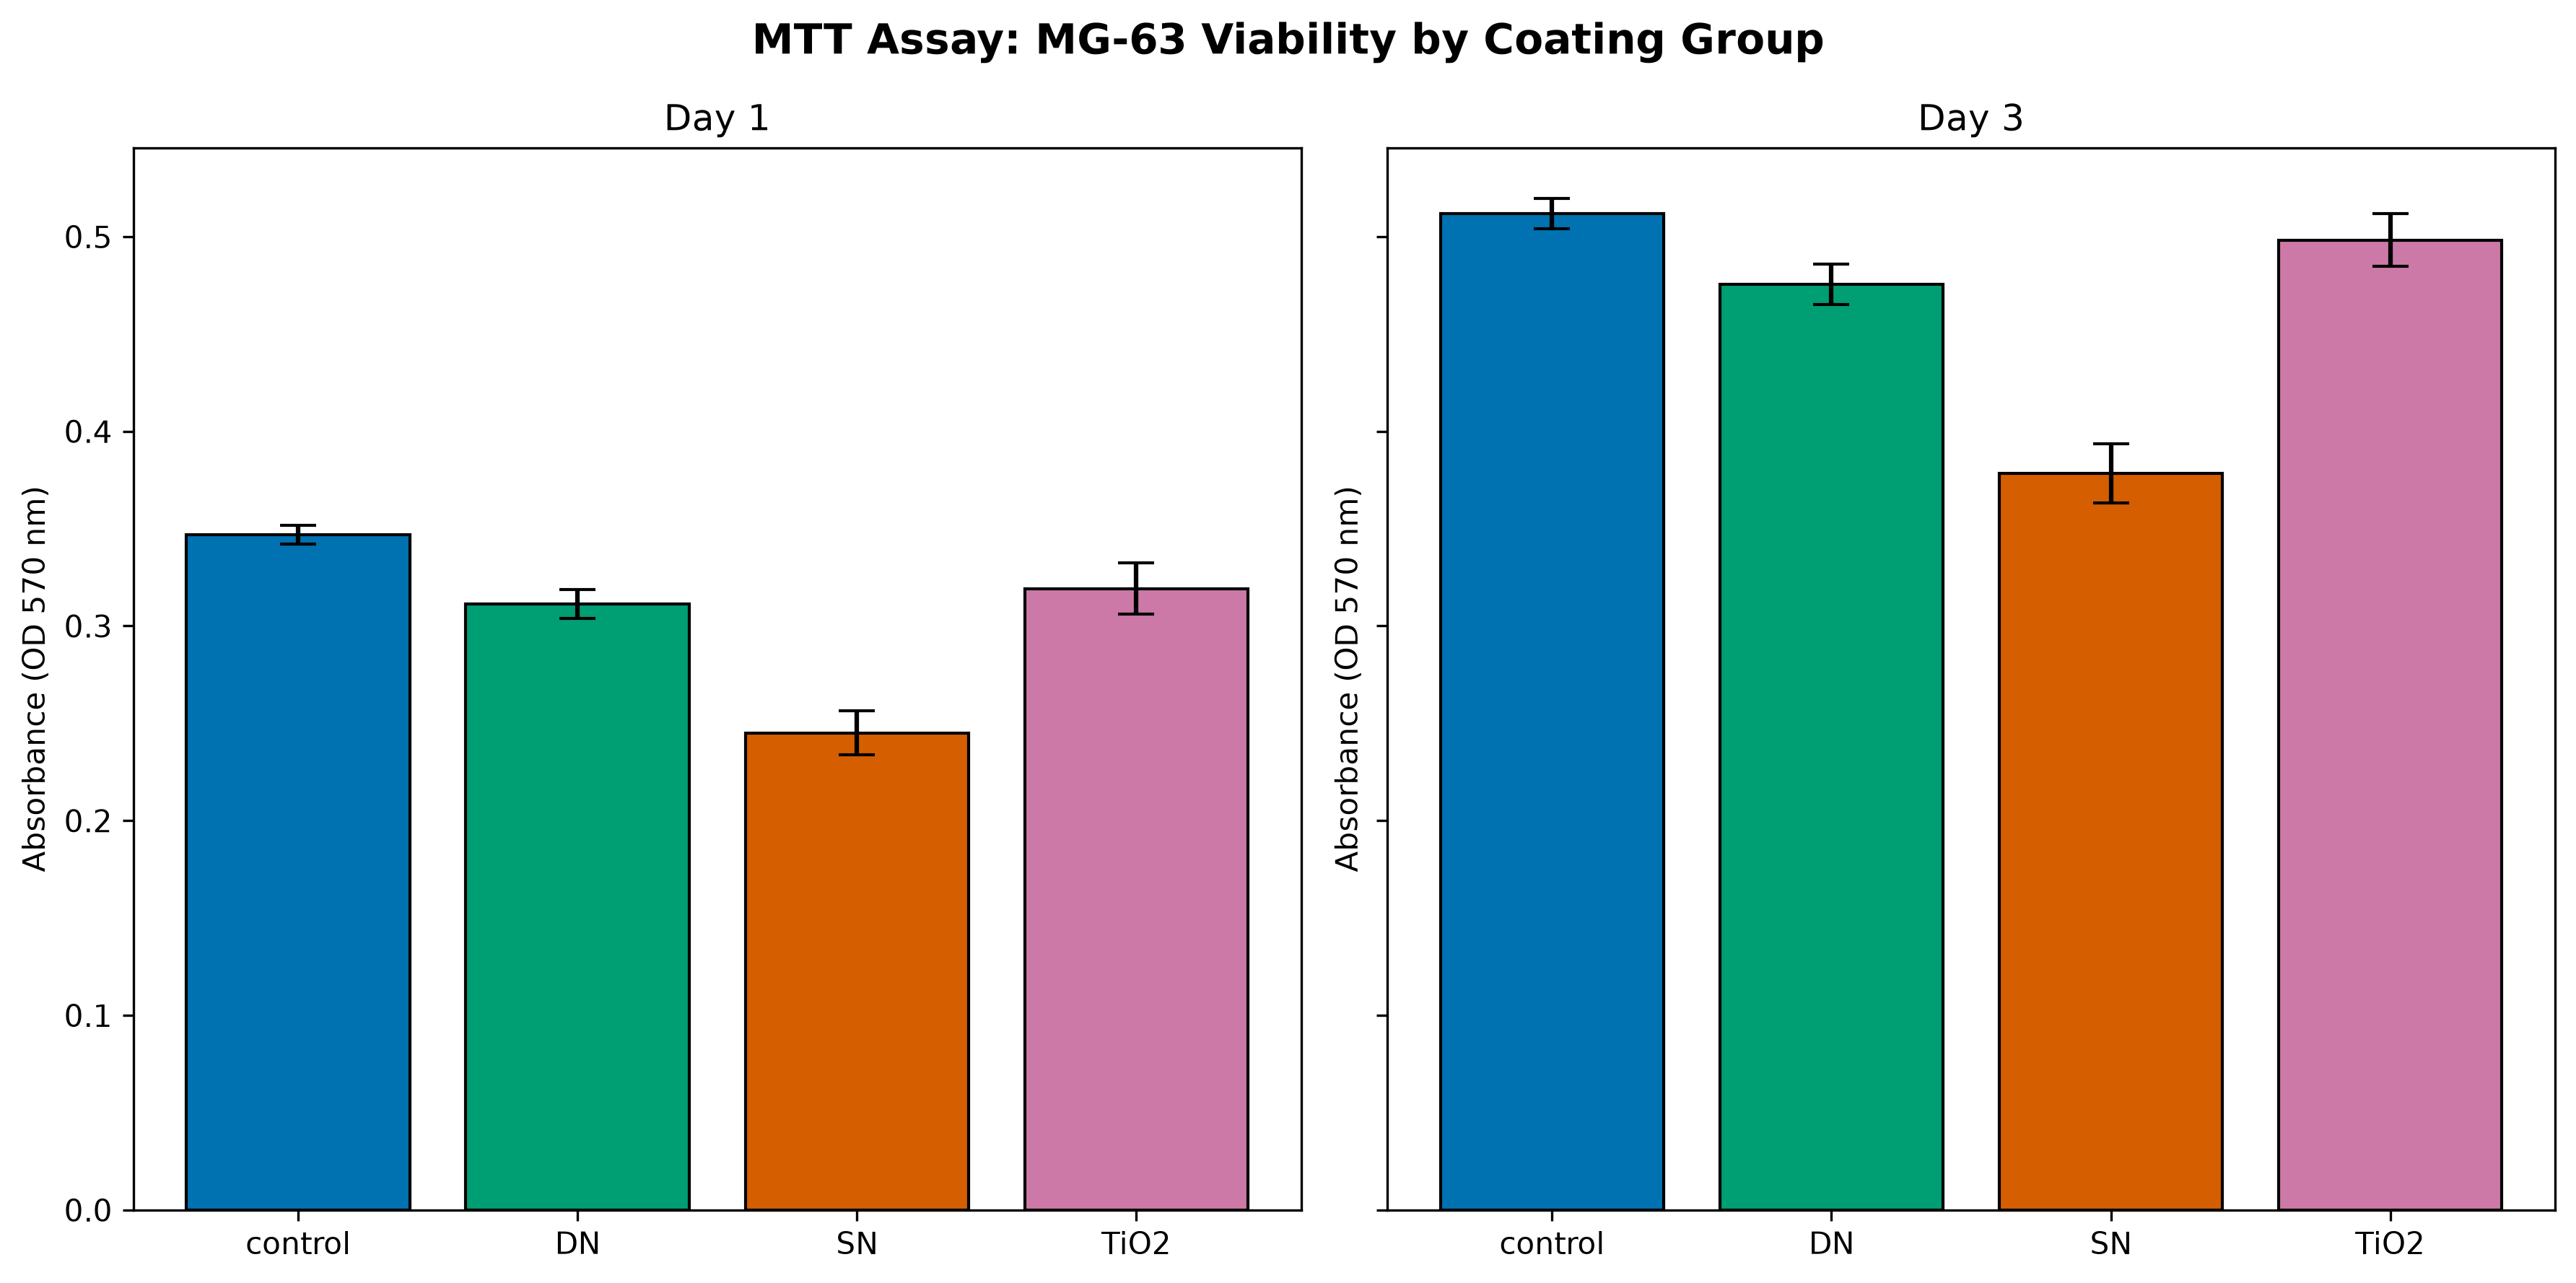

In [12]:
from IPython.display import Image, display
display(Image(filename='figures/01_absorbance_bar.png'))

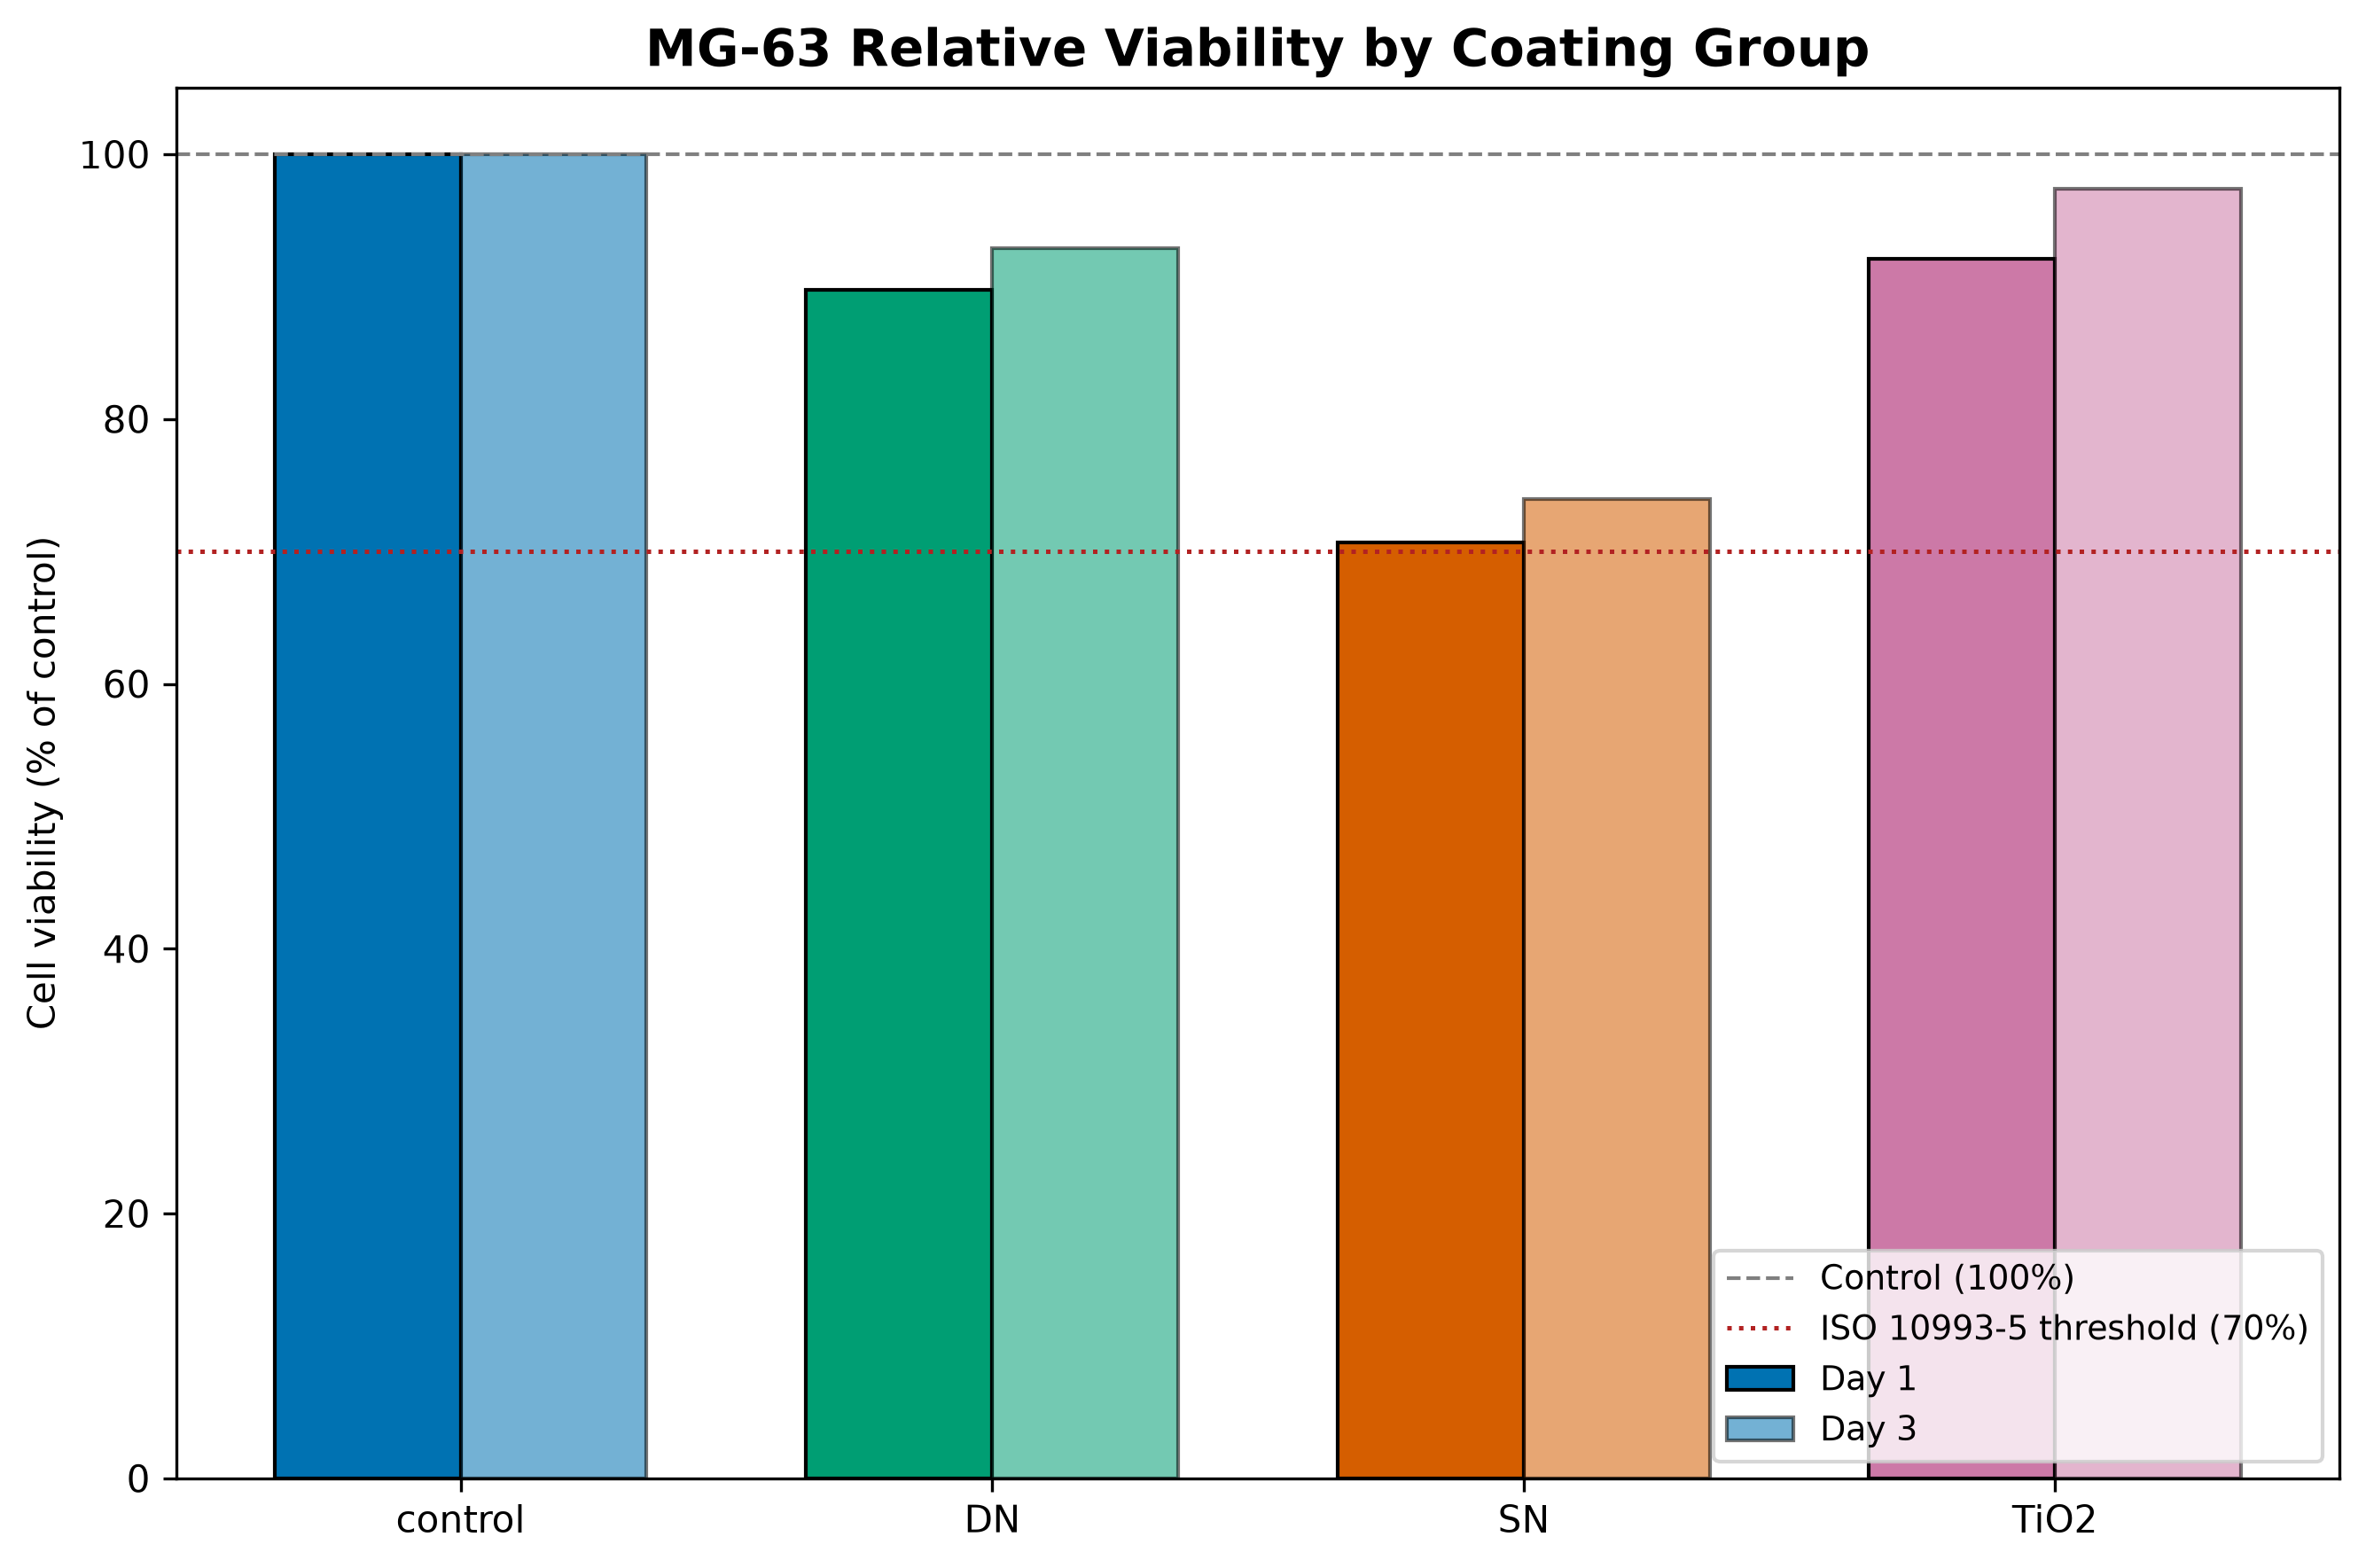

In [13]:
display(Image(filename='figures/02_viability_percent.png'))

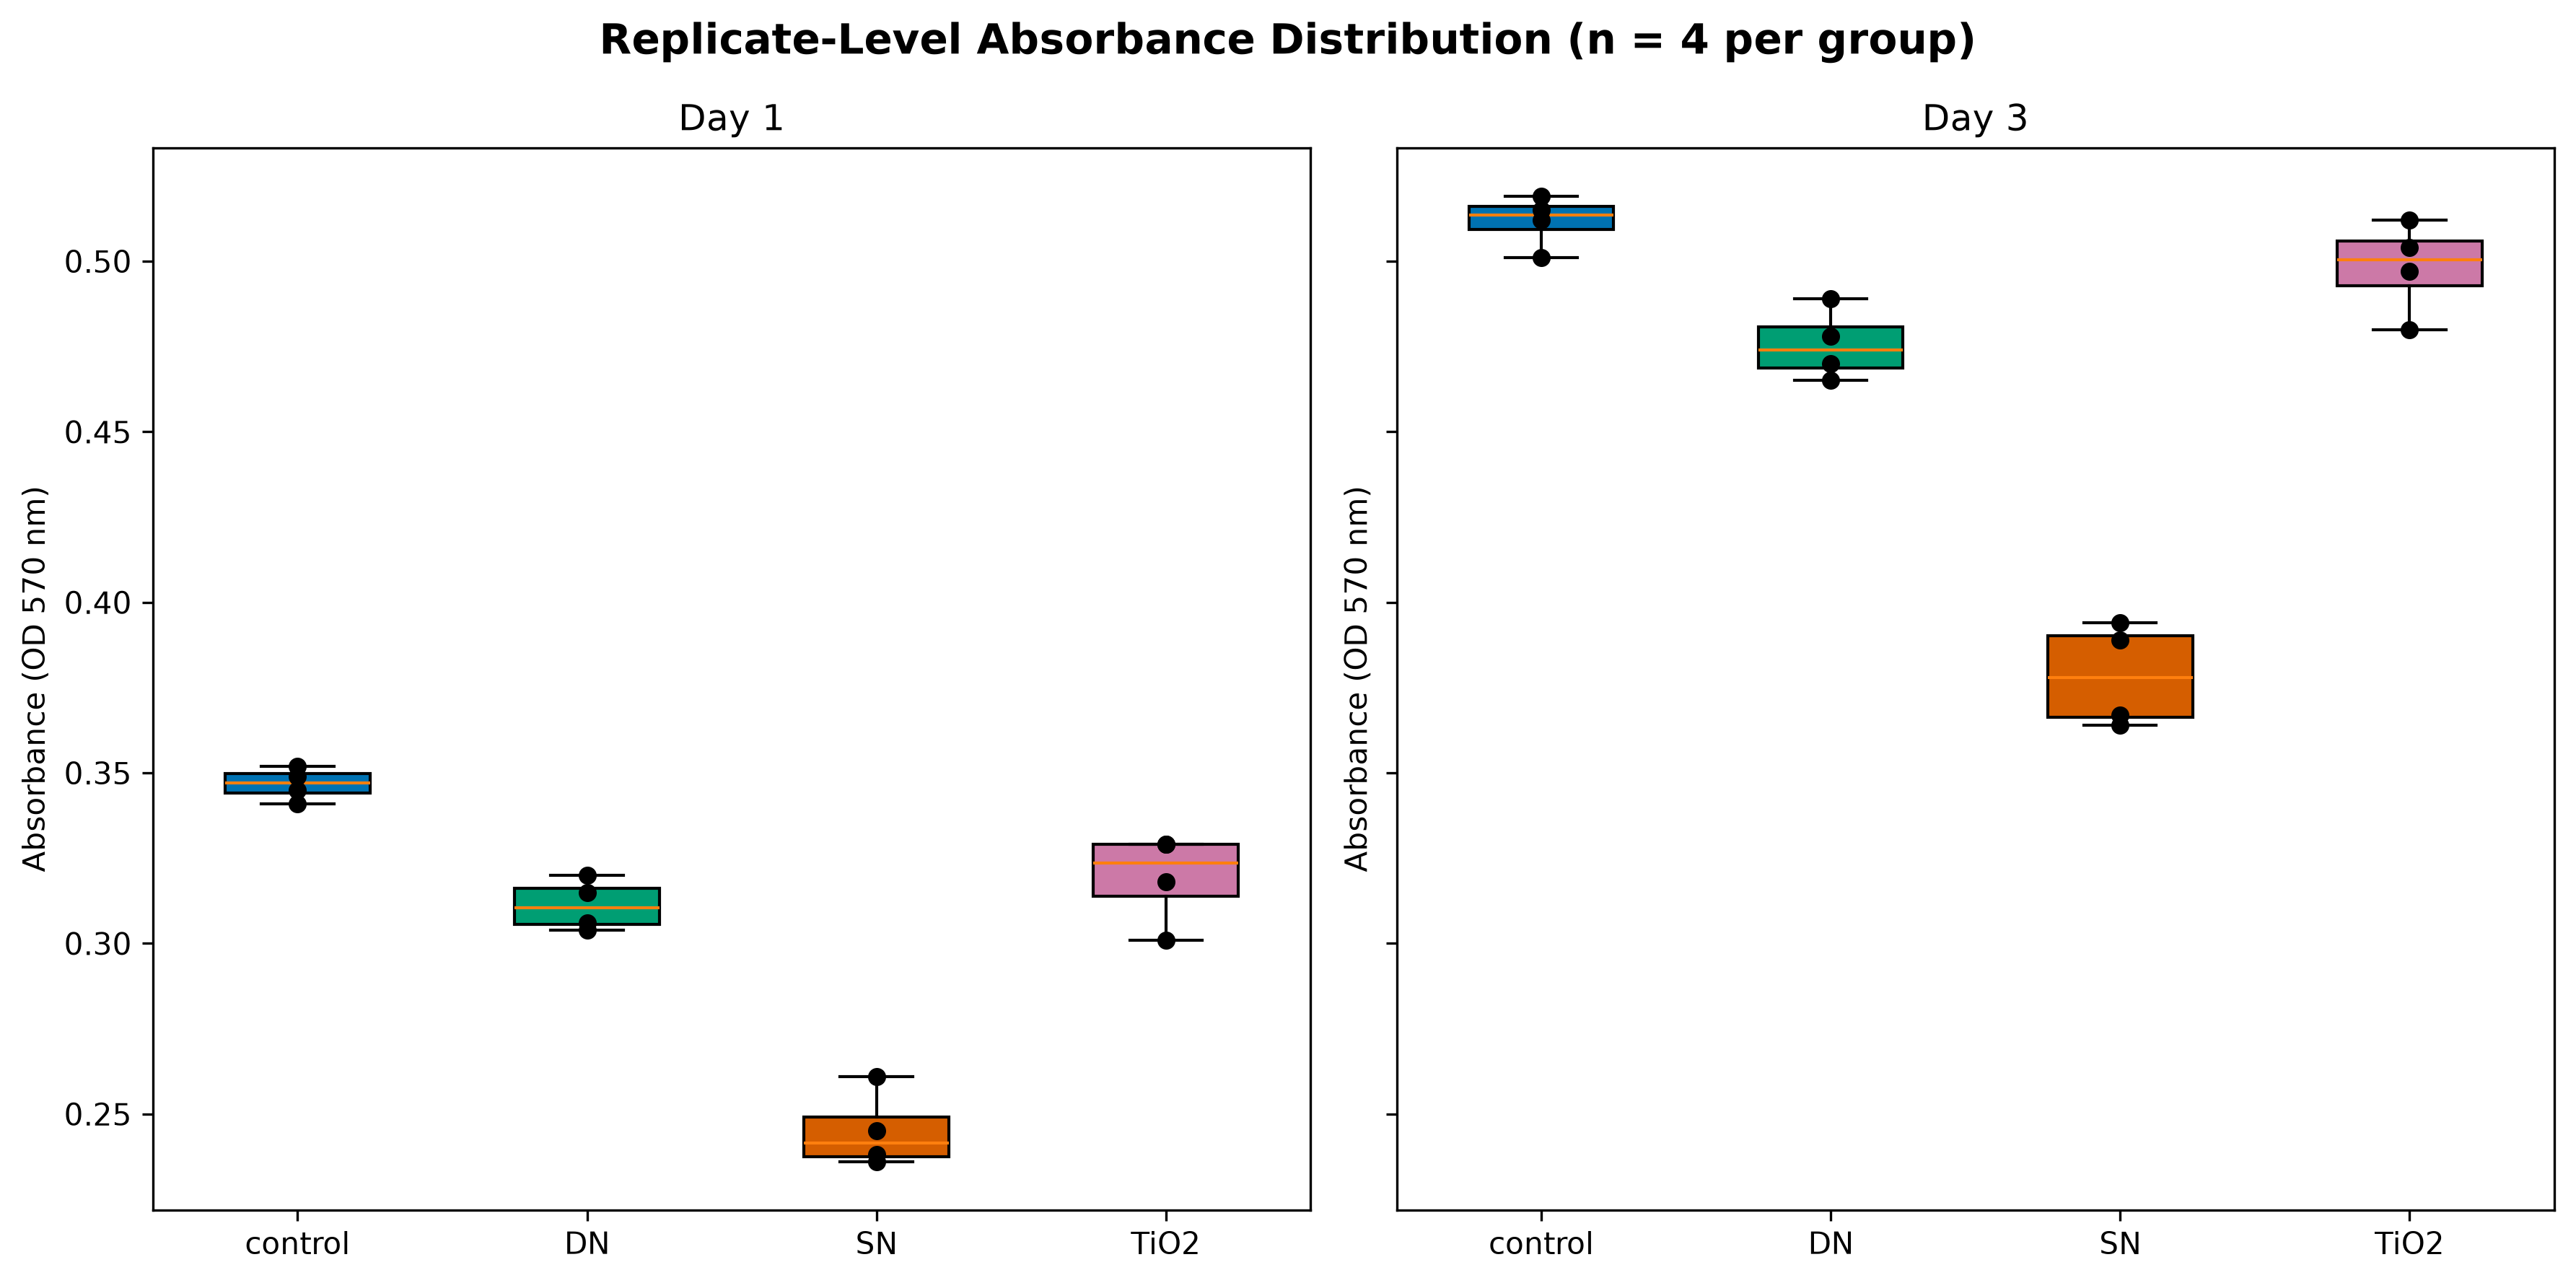

In [14]:
display(Image(filename='figures/03_boxplot_distribution.png'))

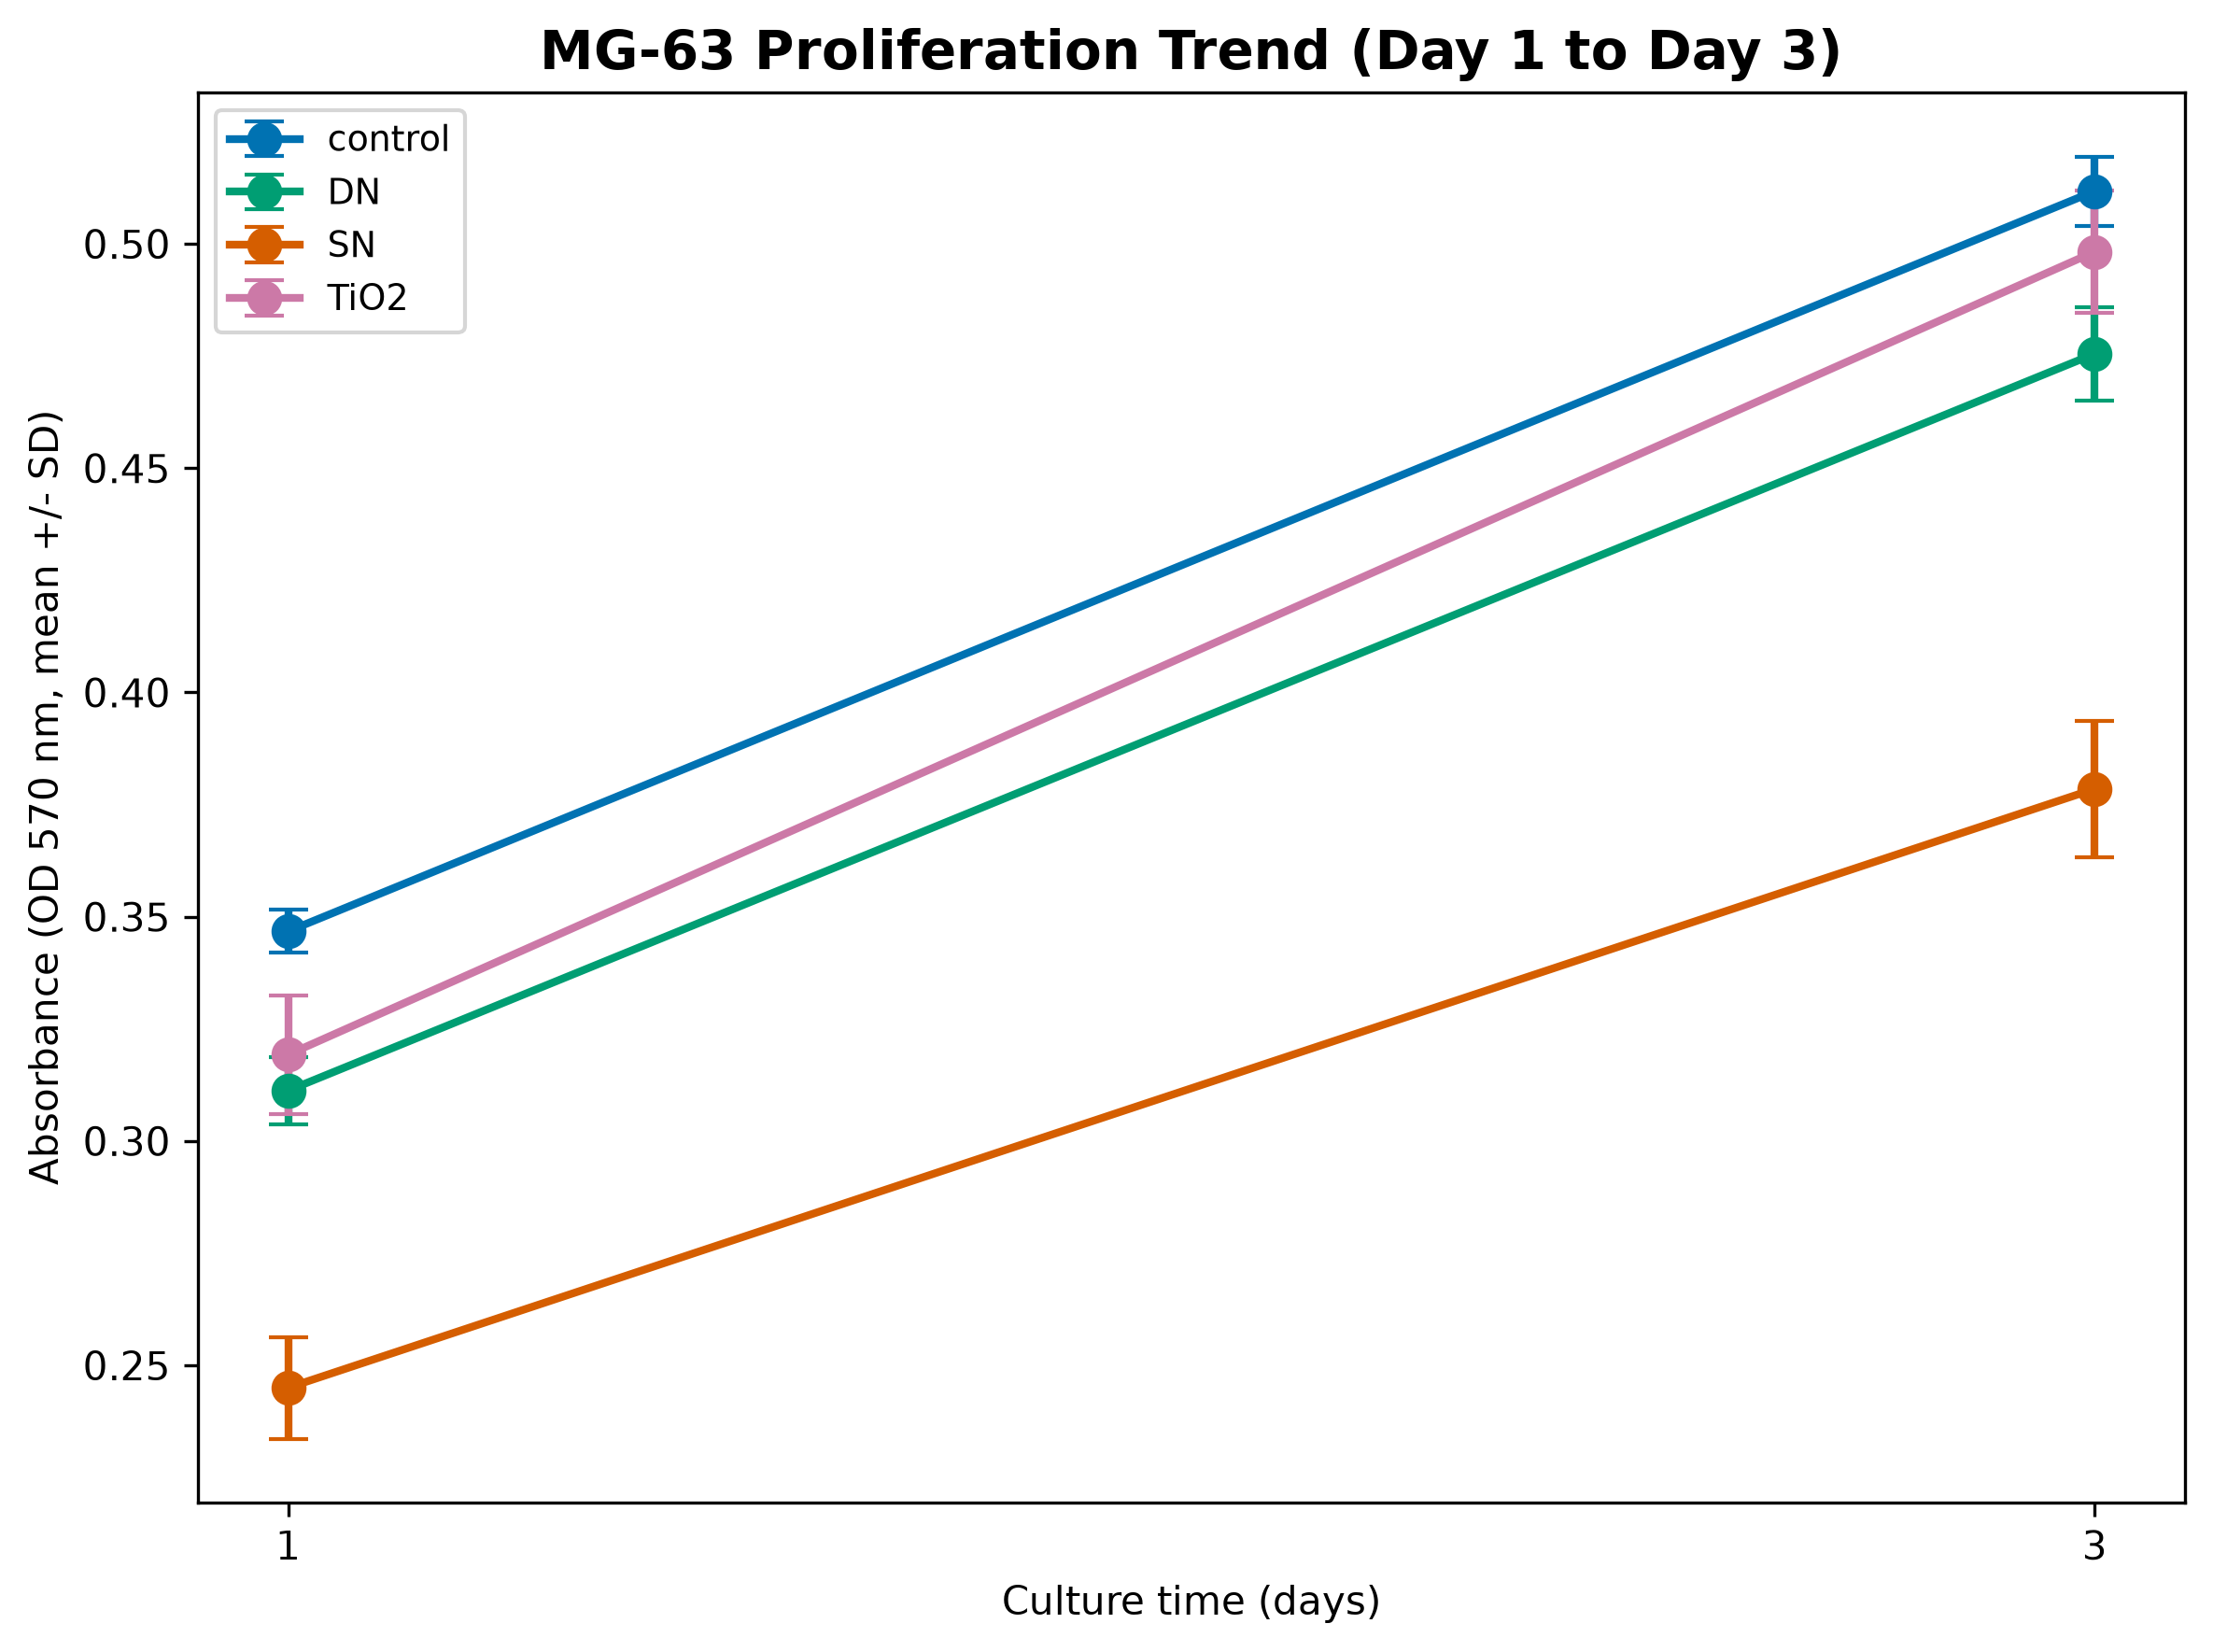

In [15]:
display(Image(filename='figures/04_proliferation_trend.png'))

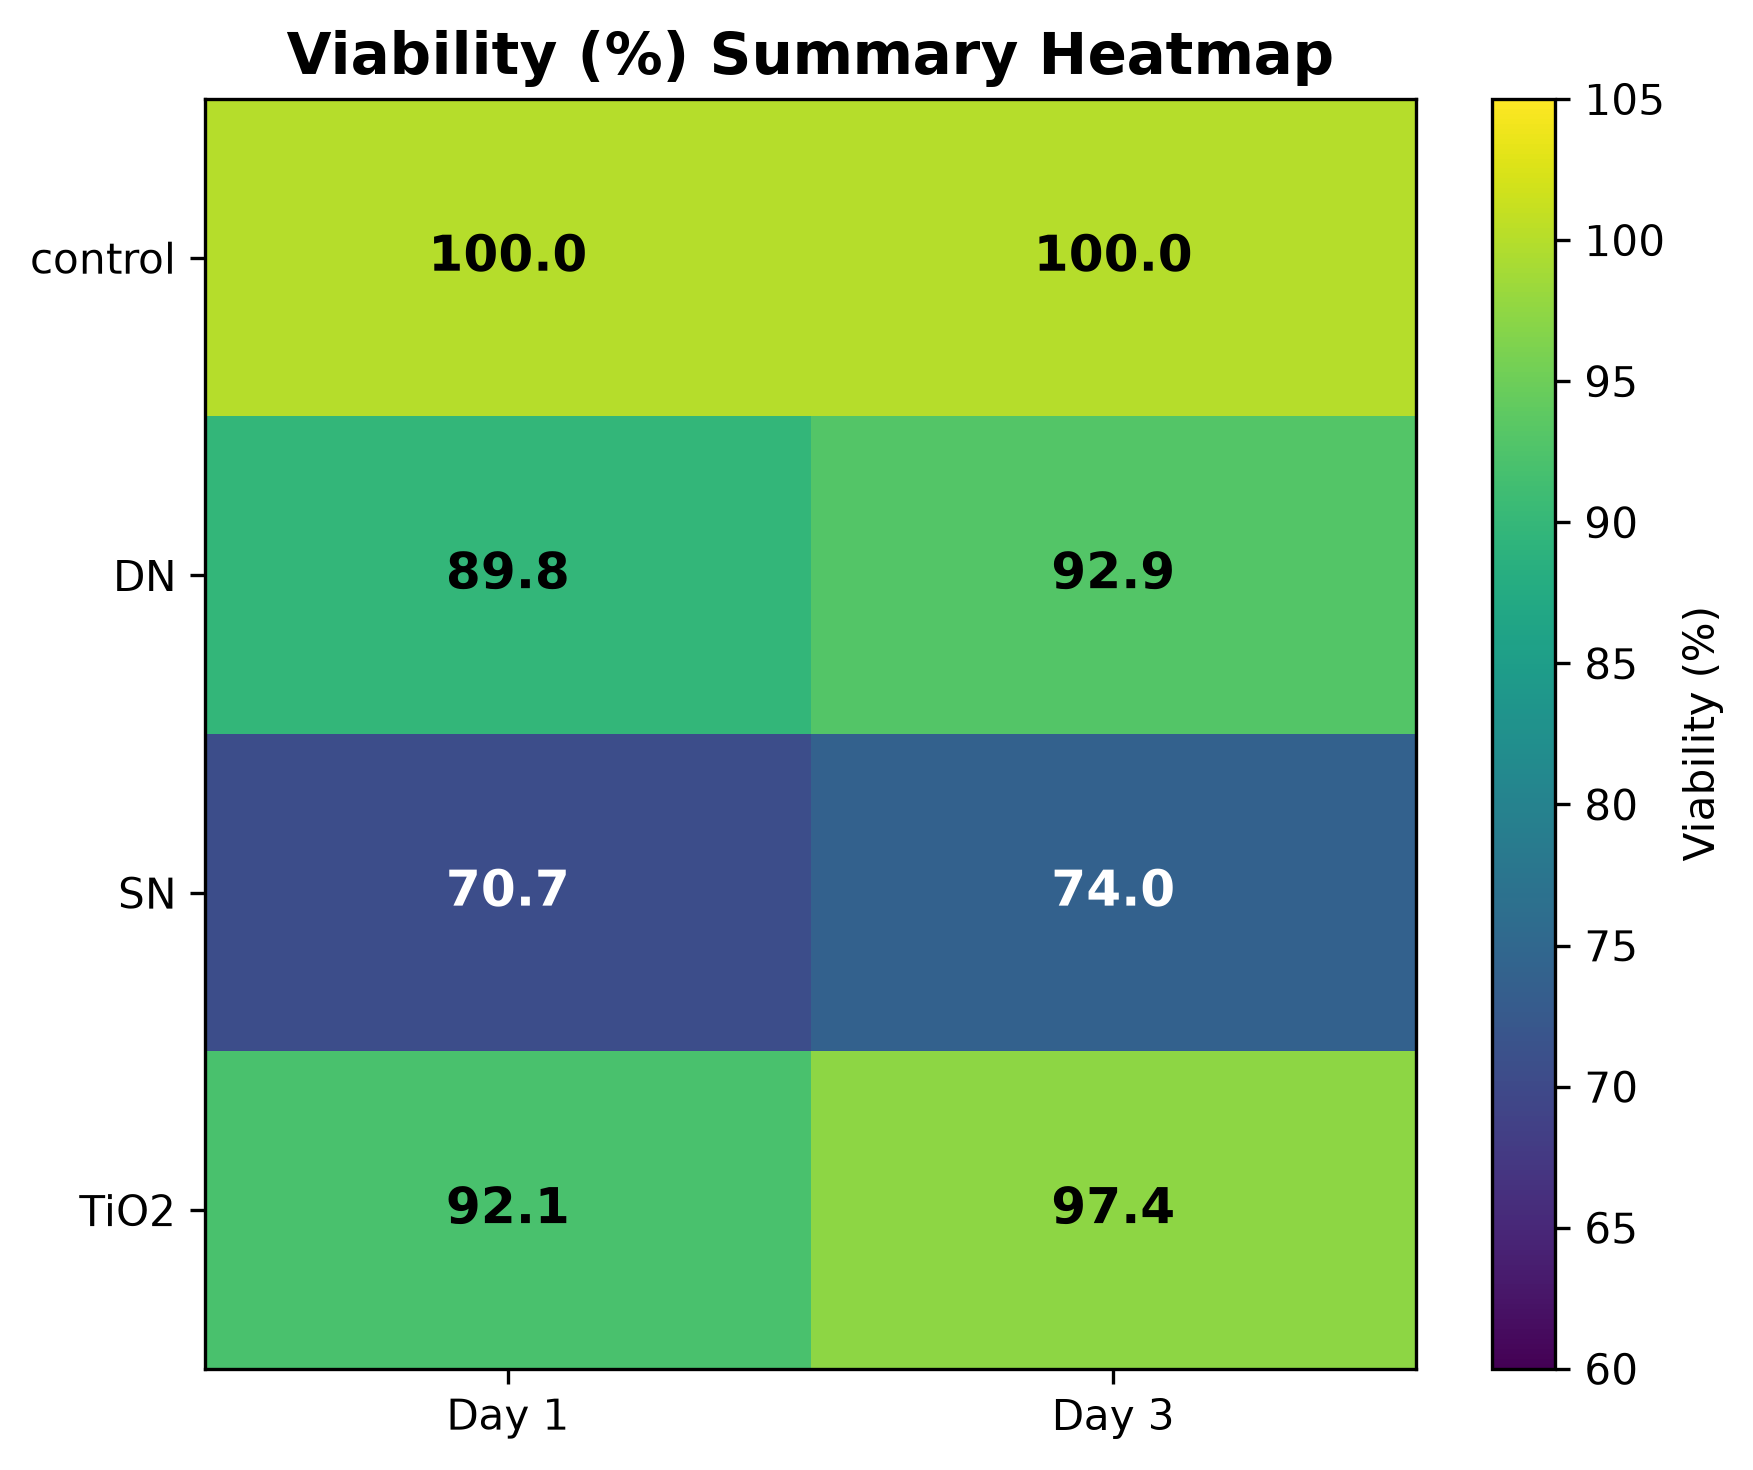

In [16]:
display(Image(filename='figures/05_viability_heatmap.png'))

## Summary & Conclusions

1. **All coatings support MG-63 viability** in the 70-97% range relative to uncoated control,
   consistent with ISO 10993-5 cytocompatibility thresholds (viability > 70% is generally
   considered non-cytotoxic).
2. **Single-nozzle TiO2/Sr (SN) coatings underperform** relative to the other groups at both
   time points (lowest viability, ~71-74%), while remaining above the ISO cytotoxicity cutoff.
3. **Dual-nozzle TiO2/Sr (DN) coatings are statistically indistinguishable from plain TiO2**
   coatings (Tukey HSD, p > 0.05 at both time points), suggesting the dual-nozzle
   electrospinning process successfully incorporates strontium without impairing short-term
   cytocompatibility.
4. **All groups proliferate significantly from Day 1 to Day 3** (p < 0.0001, fold-change
   1.48x-1.56x), indicating the coated surfaces are permissive to sustained MG-63 metabolic
   activity, not just initial attachment.
5. Full numeric outputs are exported to `report/*.csv` for direct citation in the manuscript.

**Limitation:** with n = 4 replicates per group, the statistical power of the Shapiro-Wilk and
Levene's tests to detect departures from their assumptions is limited; only extreme violations
would be reliably detected at this sample size.

---
*This notebook is part of a reproducible analysis pipeline. See `README.md` for installation
and usage instructions.*